## Section 0: Overview and Usage

This notebook implements three gate-by-gate simulations for the same validated JSON gate list:

- **Case A**: instantaneous ideal gates.
- **Case B**: pulse-level QuTiP dynamics with no dissipation.
- **Case C**: pulse-level QuTiP dynamics with dissipation from `T1`, `T2`, and optional cavity loss.

Usage:

1. Edit the configuration in **Section 2**.
2. Run the notebook top-to-bottom.
3. Compare Bloch trajectories, compact Wigner snapshots, relative phases, and weakness metrics across A/B/C.

Pulse mapping used in this notebook:

- `Displacement` -> square cavity drive.
- `Rotation` -> Gaussian qubit drive.
- `SQR` -> simplified multitone Gaussian qubit drive using `cqed_sim` dispersive manifold frequencies.


## Section 1: Imports and Environment Checks


In [1]:
from __future__ import annotations

import copy
import importlib
import importlib.metadata

REQUIRED_HINTS = {
    "numpy": "pip install numpy",
    "matplotlib": "pip install matplotlib",
    "qutip": "pip install qutip",
    "cqed_sim": "pip install -e .",
}
OPTIONAL_MODULES = ["ipywidgets"]

missing = []
versions = {}
for module_name, hint in REQUIRED_HINTS.items():
    try:
        module = importlib.import_module(module_name)
        versions[module_name] = getattr(module, "__version__", "unknown")
    except ModuleNotFoundError as exc:
        missing.append((module_name, hint, exc))

if missing:
    lines = ["Missing required notebook dependencies:"]
    for module_name, hint, exc in missing:
        lines.append(f"  - {module_name}: {exc}. Minimal install hint: {hint}")
    raise ModuleNotFoundError("\n".join(lines))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from IPython.display import Markdown, display

import cqed_sim
from cqed_sim.io.gates import load_gate_sequence, render_gate_table
from cqed_sim.observables.weakness import attach_weakness_metrics, comparison_metrics
from cqed_sim.plotting.bloch_plots import plot_bloch_track
from cqed_sim.plotting.phase_plots import plot_relative_phase_track
from cqed_sim.plotting.weakness_plots import (
    plot_cavity_population_comparison,
    plot_component_comparison,
    plot_weakness,
    print_mapping_rows,
)
from cqed_sim.plotting.wigner_grids import plot_wigner_grid
from cqed_sim.simulators.common import final_case_summary
from cqed_sim.simulators.ideal import run_case_a
from cqed_sim.simulators.pulse_open import run_case_c
from cqed_sim.simulators.pulse_unitary import run_case_b
from cqed_sim.tests.test_sanity import baseline_vs_refactor_sanity, run_notebook_sanity_suite

def package_version(dist_name: str, default: str = "editable/local") -> str:
    try:
        return importlib.metadata.version(dist_name)
    except importlib.metadata.PackageNotFoundError:
        return default

optional_versions = {}
for module_name in OPTIONAL_MODULES:
    try:
        module = importlib.import_module(module_name)
        optional_versions[module_name] = getattr(module, "__version__", "available")
    except ModuleNotFoundError:
        optional_versions[module_name] = "not installed"

np.set_printoptions(precision=4, suppress=True)
print("Required versions:")
print(f"  numpy     : {versions['numpy']}")
print(f"  matplotlib: {versions['matplotlib']}")
print(f"  qutip     : {versions['qutip']}")
print(f"  cqed_sim  : {package_version('cqed-sim')}")
print("Optional:")
for name, version in optional_versions.items():
    print(f"  {name:<10}: {version}")


Required versions:
  numpy     : 1.26.4
  matplotlib: 3.10.0
  qutip     : 5.1.1
  cqed_sim  : 0.1.0
Optional:
  ipywidgets: 8.1.5


## Section 2: User Configuration


In [2]:
CONFIG = {
    "json_path": r"C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\decomposition\cluster_U_T_1-1e+03ns-3_sqr-no_phases.josn",
    "cavity_fock_cutoff": 24,
    "initial_qubit": "g",
    "initial_cavity_kind": "fock",
    "initial_cavity_fock": 0,
    "initial_cavity_alpha": {"re": 0.0, "im": 0.0},
    "initial_cavity_amplitudes": None,
    "wigner_every_gate": True,
    "wigner_stride": 1,
    "wigner_points": 81,
    "wigner_extent": 4.0,
    "wigner_max_cols": 5,
    "top_axis_label_stride": 1,
    "summary_max_rows": 20,
    "phase_track_max_n": 2,
    "phase_reference_threshold": 1.0e-8,
    "phase_unwrap": False,
    "dt_s": 1.0e-9,
    "max_step_s": 1.0e-9,
    "duration_displacement_s": 48.0e-9,
    "duration_rotation_s": 16.0e-9,
    "duration_sqr_s": 1.0e-6,
    "rotation_sigma_fraction": 1/6,
    "sqr_sigma_fraction": 1/6,
    "sqr_theta_cutoff": 1.0e-10,
    "use_rotating_frame": True,
    "omega_c_hz": 0.0,
    "omega_q_hz": 0.0,
    "qubit_alpha_hz": 0.0,
    "st_chi_hz": -2840421.354241756,
    "st_chi2_hz": -21912.638362342423,
    "st_chi3_hz": -327.37857577643325,
    "st_K_hz": -28844.0,
    "st_K2_hz": 1406.0,
    "cavity_kappa_1_per_s": 0.0,
    "qb_T1_relax_ns": 98120.873848245112,
    "qb_T2_ramsey_ns": 63240.73112712837,
    "qb_T2_echo_ns": 80700.0,
    "t2_source": "ramsey",
}
CONFIG["n_cav_dim"] = int(CONFIG["cavity_fock_cutoff"]) + 1

display(Markdown("Configured parameters:"))
for key in sorted(CONFIG):
    print(f"{key:>24}: {CONFIG[key]}")


Configured parameters:

      cavity_fock_cutoff: 24
    cavity_kappa_1_per_s: 0.0
                    dt_s: 1e-09
 duration_displacement_s: 4.8e-08
     duration_rotation_s: 1.6e-08
          duration_sqr_s: 1e-06
    initial_cavity_alpha: {'re': 0.0, 'im': 0.0}
initial_cavity_amplitudes: None
     initial_cavity_fock: 0
     initial_cavity_kind: fock
           initial_qubit: g
               json_path: C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\decomposition\cluster_U_T_1-1e+03ns-3_sqr-no_phases.josn
              max_step_s: 1e-09
               n_cav_dim: 25
              omega_c_hz: 0.0
              omega_q_hz: 0.0
phase_reference_threshold: 1e-08
       phase_track_max_n: 2
            phase_unwrap: False
          qb_T1_relax_ns: 98120.87384824512
           qb_T2_echo_ns: 80700.0
         qb_T2_ramsey_ns: 63240.73112712837
          qubit_alpha_hz: 0.0
 rotation_sigma_fraction: 0.16666666666666666
      sqr_sigma_fraction: 0.16666666666666666
      

## Section 3: Load and Validate JSON Gate List


In [3]:
GATE_PATH, GATES = load_gate_sequence(CONFIG["json_path"])
print(f"Loaded {len(GATES)} gates from:\n  {GATE_PATH}")
render_gate_table(GATES, max_rows=int(CONFIG["summary_max_rows"]))


Loaded 10 gates from:
  C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\decomposition\cluster_U_T_1-1e+03ns-3_sqr-no_phases
  #  Type         Target   Name                                     Params
--------------------------------------------------------------------------
  0  Displacement storage  Disp_+0.382_-0.005                       alpha=+0.382-0.005j
  1  Rotation     qubit    Rotation_-2.2142823374858827_-1.56912986 theta=-2.214, phi=-1.569
  2  SQR          qubit    SQR_527e17733de113ecaead4876b2bcafeb     tones=12, active=1
  3  Displacement storage  Disp_-0.791_+0.004                       alpha=-0.791+0.004j
  4  Rotation     qubit    Rotation_-1.024328231656325_1.5603378419 theta=-1.024, phi=+1.560
  5  SQR          qubit    SQR_bc8194a85a260be4c0959c6c4d8d7ae1     tones=12, active=1
  6  Displacement storage  Disp_+0.763_-0.002                       alpha=+0.763-0.002j
  7  Rotation     qubit    Rotation_-1.2144143222850552_

## Section 4: Shared Operator Builders and Utilities


In [4]:
SHARED_API = [
    "run_case_a",
    "run_case_b",
    "run_case_c",
    "plot_bloch_track",
    "plot_wigner_grid",
    "plot_relative_phase_track",
    "plot_component_comparison",
    "plot_weakness",
    "run_notebook_sanity_suite",
]

print("Notebook orchestration uses cqed_sim package helpers:")
for name in SHARED_API:
    print(f"  - {name}")

import importlib as _importlib
import cqed_sim.plotting.wigner_grids as _wigner_grids

_importlib.reload(_wigner_grids)
plot_wigner_grid = _wigner_grids.plot_wigner_grid


def elapsed_time_axis_s(track, config):
    rows = list(track.get("metadata", {}).get("mapping_rows", []))
    if len(rows) == len(track["snapshots"]) - 1 and all("duration_s" in row for row in rows):
        times = [0.0]
        for row in rows:
            times.append(times[-1] + float(row["duration_s"]))
        return np.asarray(times, dtype=float)

    duration_by_gate = {
        "Displacement": float(config["duration_displacement_s"]),
        "Rotation": float(config["duration_rotation_s"]),
        "SQR": float(config["duration_sqr_s"]),
    }
    times = [0.0]
    for snap in track["snapshots"][1:]:
        times.append(times[-1] + duration_by_gate.get(str(snap["gate_type"]), 0.0))
    return np.asarray(times, dtype=float)


def plot_pulse_bloch_and_phase_vs_time(track, config, max_n, threshold, unwrap):
    from cqed_sim.observables.phases import relative_phase_diagnostics
    from cqed_sim.plotting.bloch_plots import GATE_COLORS

    indices = np.asarray(track["indices"], dtype=int)
    t_us = elapsed_time_axis_s(track, config) * 1.0e6
    diagnostics = relative_phase_diagnostics(track, max_n=max_n, threshold=threshold, unwrap=unwrap)

    fig, (ax_bloch, ax_phase) = plt.subplots(2, 1, figsize=(11.0, 8.0), sharex=True)

    ax_bloch.plot(indices, track["x"], "o-", label=r"$\langle \sigma_x \rangle$")
    ax_bloch.plot(indices, track["y"], "o-", label=r"$\langle \sigma_y \rangle$")
    ax_bloch.plot(indices, track["z"], "o-", label=r"$\langle \sigma_z \rangle$")
    for snap in track["snapshots"][1:]:
        idx = int(snap["index"])
        ax_bloch.axvline(
            idx,
            color=GATE_COLORS.get(snap["gate_type"], "black"),
            alpha=0.08,
            linewidth=1.0,
        )
    ax_bloch.set_title(f"{track['case']}: pulse-level Bloch trajectory and relative phase vs gate index")
    ax_bloch.set_ylabel("Bloch component")
    ax_bloch.set_ylim(-1.05, 1.05)
    ax_bloch.grid(alpha=0.25)
    ax_bloch.legend(loc="lower right", ncol=3)

    for label in diagnostics["labels"]:
        linestyle = "-" if label == "|g0|" else "--" if label.startswith("|g") else "-."
        linewidth = 2.2 if label == "|g0|" else 1.8
        ax_phase.plot(indices, diagnostics["traces"][label], linestyle=linestyle, linewidth=linewidth, label=label)
    for snap in track["snapshots"][1:]:
        idx = int(snap["index"])
        ax_phase.axvline(
            idx,
            color=GATE_COLORS.get(snap["gate_type"], "black"),
            alpha=0.08,
            linewidth=1.0,
        )
    ax_phase.set_xlabel("Gate index")
    ax_phase.set_ylabel("Relative phase [rad]")
    ax_phase.set_xticks(indices)
    ax_phase.grid(alpha=0.25)
    ax_phase.legend(loc="best", ncol=3)

    label_stride = max(1, int(config.get("top_axis_label_stride", 1)))
    top = ax_bloch.twiny()
    top.set_xlim(ax_bloch.get_xlim())
    tick_indices = [int(i) for i in indices if int(i) % label_stride == 0]
    if int(indices[-1]) not in tick_indices:
        tick_indices.append(int(indices[-1]))
    top.set_xticks(tick_indices)
    top.set_xticklabels([f"{t_us[i]:.3f}" for i in tick_indices], rotation=45, ha="left", fontsize=8)
    top.set_xlabel("Elapsed time [μs]")

    fig.tight_layout()
    return fig


Notebook orchestration uses cqed_sim package helpers:
  - run_case_a
  - run_case_b
  - run_case_c
  - plot_bloch_track
  - plot_wigner_grid
  - plot_relative_phase_track
  - plot_component_comparison
  - plot_weakness
  - run_notebook_sanity_suite


## Section 5: Case A --- Ideal Gate Simulation


Case A diagnostics:
{'solver': 'instantaneous_unitary', 'final_x': 0.005061829077818567, 'final_y': 0.0005559005790004141, 'final_z': 0.9995098045492457, 'final_n': 0.5095751996537795}


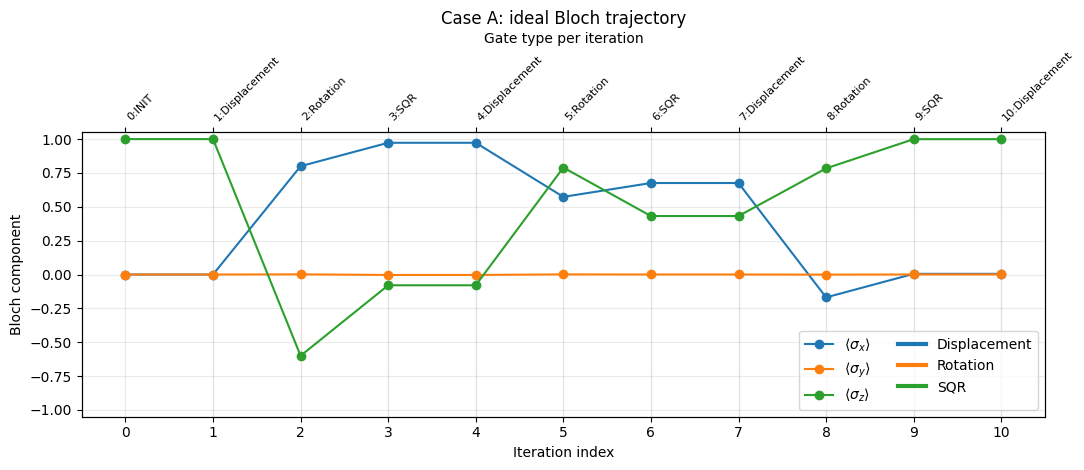

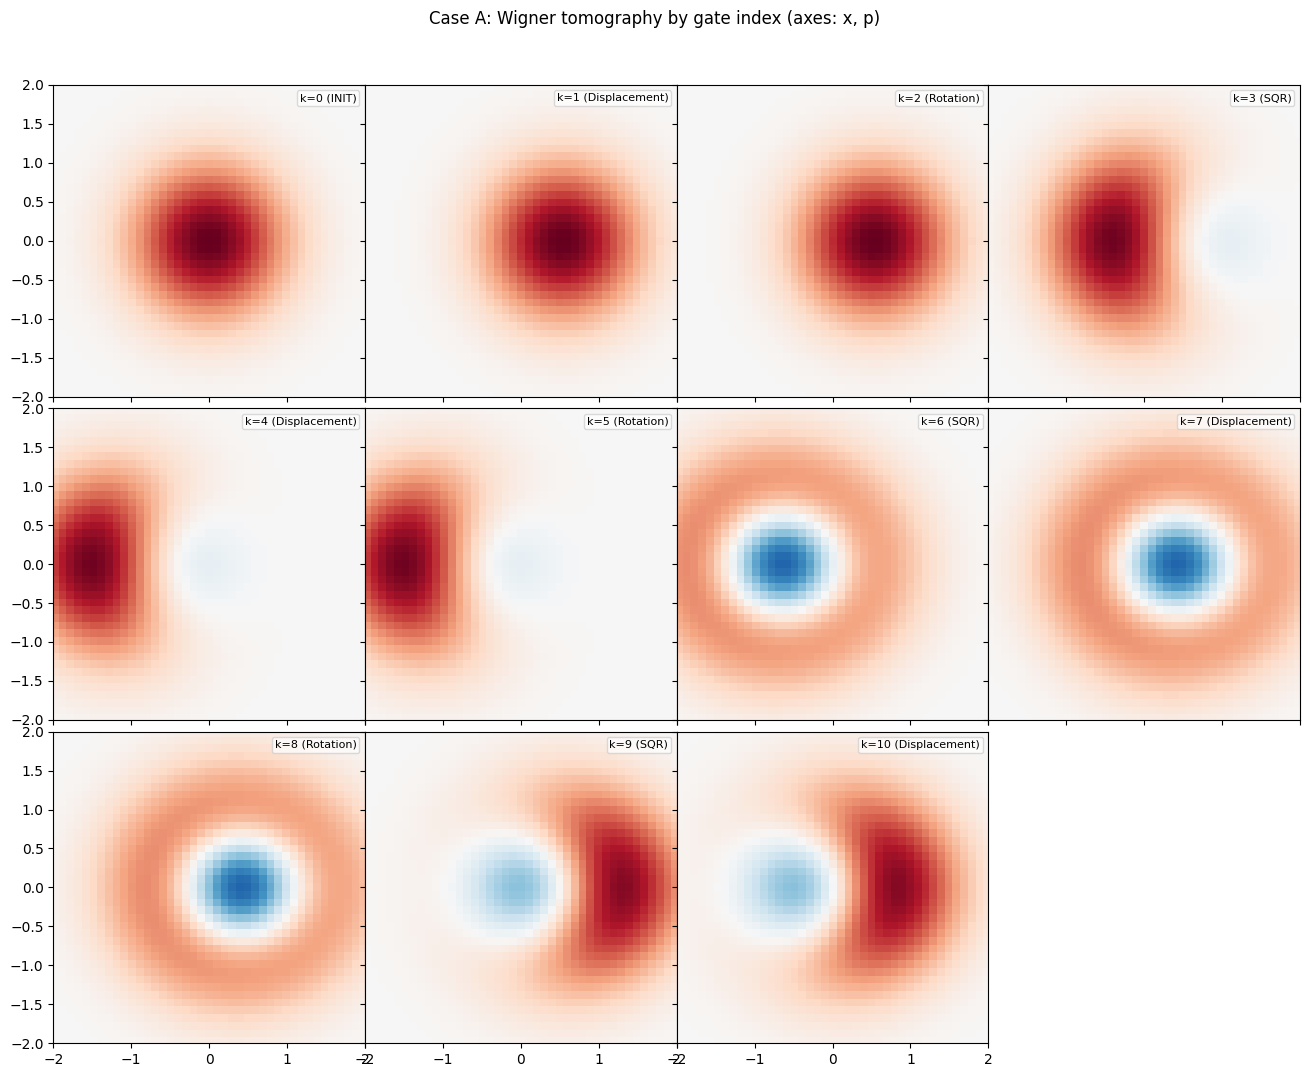

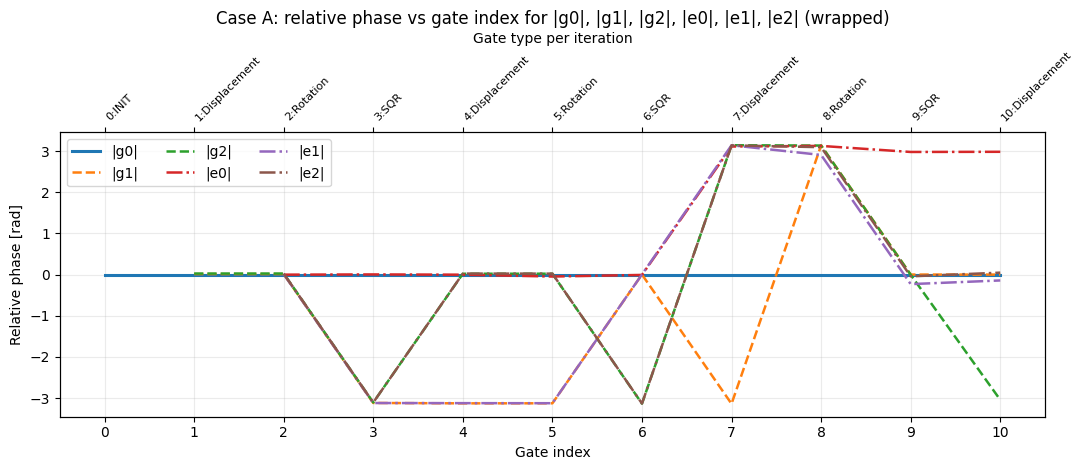

In [5]:
CASE_A = run_case_a(GATES, CONFIG, case_label="Case A")

print("Case A diagnostics:")
print(
    {
        "solver": CASE_A["metadata"]["solver"],
        "final_x": CASE_A["x"][-1],
        "final_y": CASE_A["y"][-1],
        "final_z": CASE_A["z"][-1],
        "final_n": CASE_A["n"][-1],
    }
)

plot_bloch_track(
    CASE_A,
    title="Case A: ideal Bloch trajectory",
    label_stride=int(CONFIG["top_axis_label_stride"]),
)
plt.show()

plot_wigner_grid(
    CASE_A,
    title="Case A: Wigner tomography by gate index",
    stride=int(CONFIG["wigner_stride"]),
    max_cols=int(CONFIG["wigner_max_cols"]),
    show_colorbar=False,
)
plt.show()

plot_relative_phase_track(
    CASE_A,
    max_n=int(CONFIG["phase_track_max_n"]),
    threshold=float(CONFIG["phase_reference_threshold"]),
    unwrap=bool(CONFIG["phase_unwrap"]),
    label_stride=int(CONFIG["top_axis_label_stride"]),
)
plt.show()


## Section 6: Case B --- Pulse-level Simulation (No Dissipation)

SQR note:

`cqed_sim` provides dispersive manifold-frequency helpers, but not a hardware-calibrated selective-SQR compiler. This notebook therefore uses a simplified multitone Gaussian rotating-wave model:

- one Gaussian-windowed tone per active Fock manifold,
- tone frequencies from `cqed_sim.snap_opt.model.manifold_transition_frequency(...)`,
- per-tone area calibration `theta_n ≈ 2 * ∫ Ω_n(t) dt`.


Case B diagnostics:
{'solver': 'sesolve', 'final_x': -0.7401609584505687, 'final_y': -0.567592646609592, 'final_z': 0.2769836835148276, 'final_n': 0.5186464627518249}
Case B gate-to-pulse mapping:
k= 1 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.
k= 2 Rotation     Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.
k= 3 SQR          Simplified multitone Gaussian SQR using cqed_sim manifold_transition_frequency(...) and per-tone RWA area calibration.
k= 4 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.
k= 5 Rotation     Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.
k= 6 SQR          Simplified multitone Gaussian SQR using cqed_sim manifold_transition_frequency(...) and per-tone RWA area calibration.
k= 7 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i *

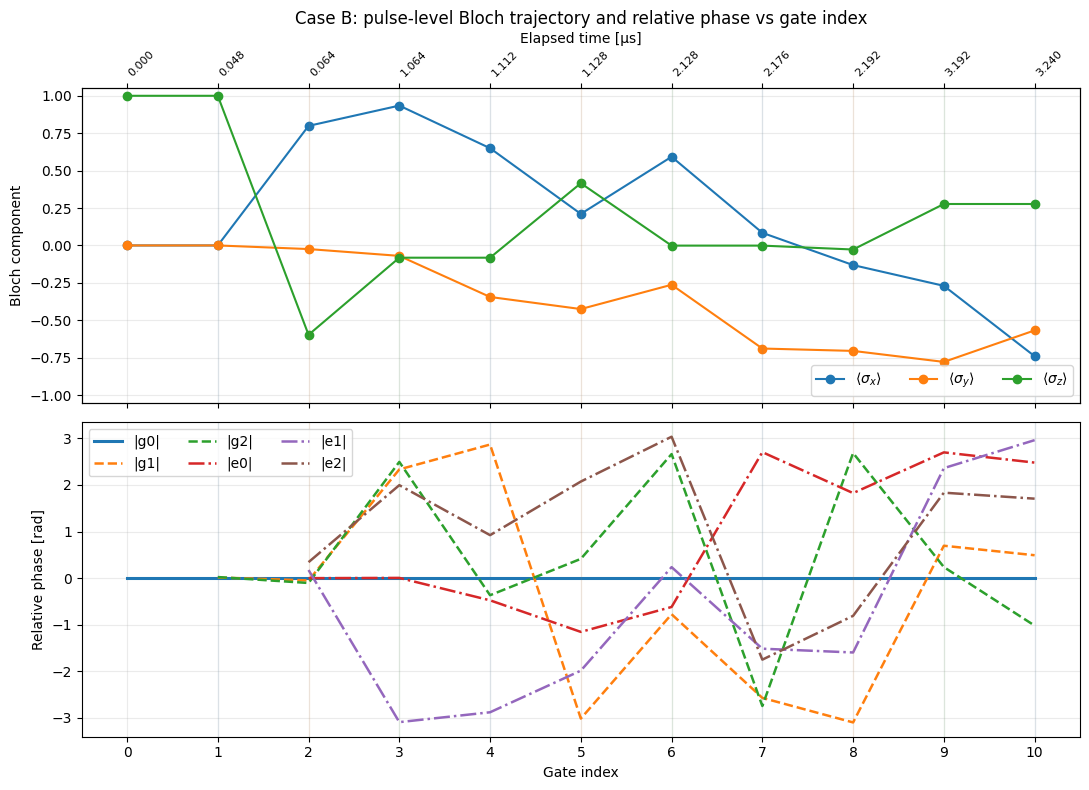

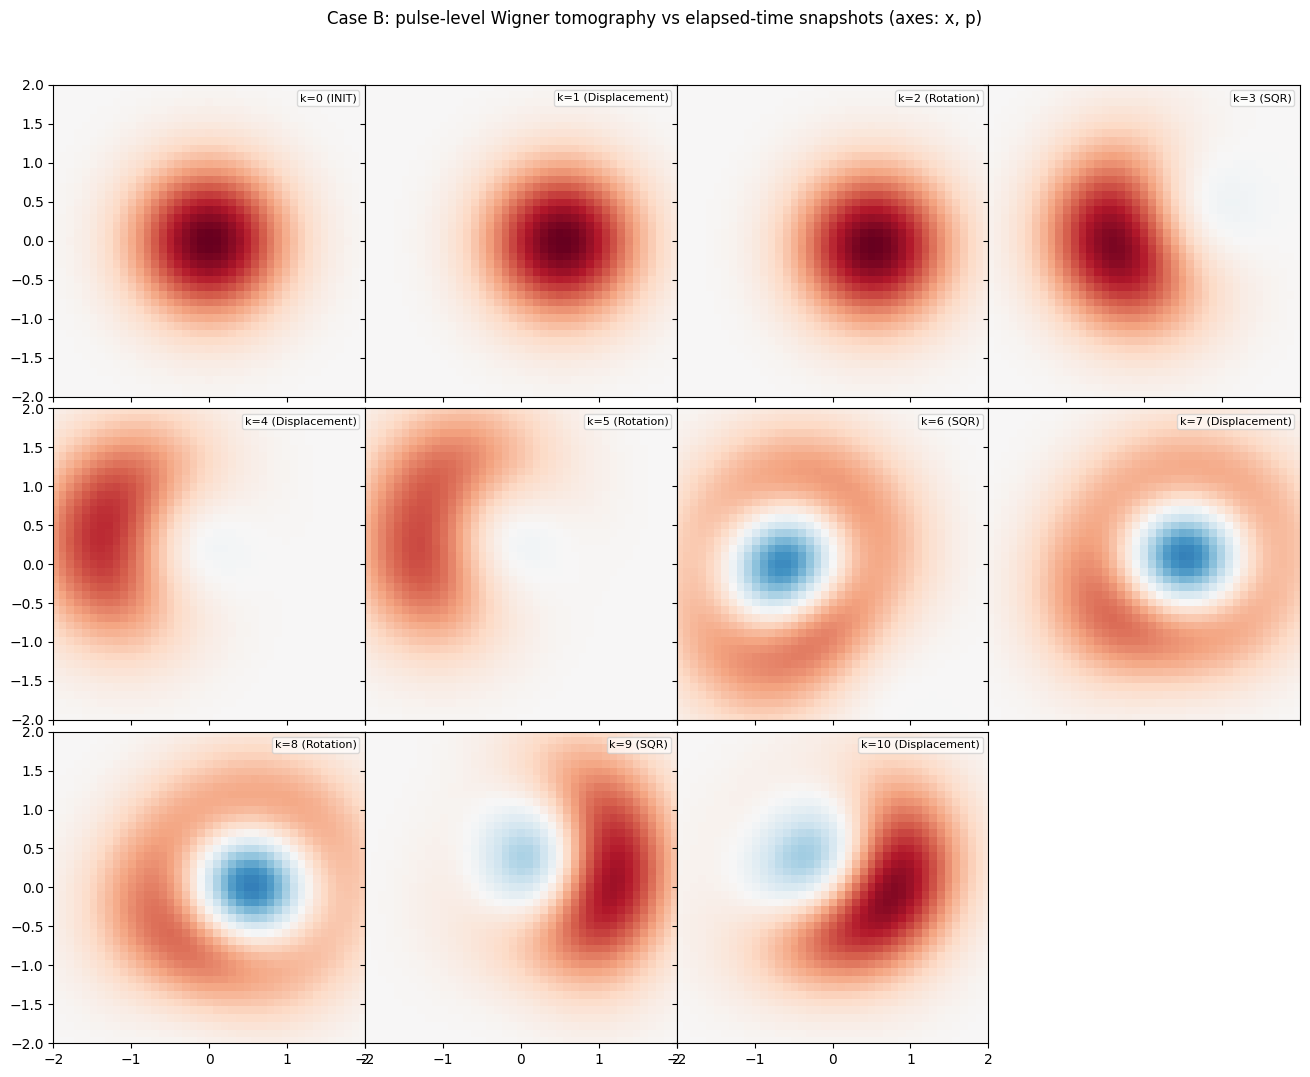

In [6]:
CASE_B = run_case_b(GATES, CONFIG, case_label="Case B")

print("Case B diagnostics:")
print(
    {
        "solver": CASE_B["metadata"]["solver"],
        "final_x": CASE_B["x"][-1],
        "final_y": CASE_B["y"][-1],
        "final_z": CASE_B["z"][-1],
        "final_n": CASE_B["n"][-1],
    }
)
print("Case B gate-to-pulse mapping:")
print_mapping_rows(CASE_B)

elapsed_b_us = elapsed_time_axis_s(CASE_B, CONFIG) * 1.0e6
print(f"Case B total elapsed time [us]: {elapsed_b_us[-1]:.6f}")

plot_pulse_bloch_and_phase_vs_time(
    CASE_B,
    CONFIG,
    max_n=int(CONFIG["phase_track_max_n"]),
    threshold=float(CONFIG["phase_reference_threshold"]),
    unwrap=bool(CONFIG["phase_unwrap"]),
)
plt.show()

plot_wigner_grid(
    CASE_B,
    title="Case B: pulse-level Wigner tomography vs elapsed-time snapshots",
    stride=int(CONFIG["wigner_stride"]),
    max_cols=int(CONFIG["wigner_max_cols"]),
    show_colorbar=False,
)
plt.show()


## Section 7: Case C --- Pulse-level Simulation (With Dissipation)


Case C diagnostics:
{'solver': 'mesolve', 'final_x': -0.7127469803684212, 'final_y': -0.5356717786236507, 'final_z': 0.27956498636619004, 'final_n': 0.5270392604717896}
{'t1_s': 9.812087384824512e-05, 'tphi_s': 9.331110334423099e-05, 'kappa_1_per_s': None, 'gamma1_1_per_s': 10191.51135513338, 'gamma_phi_prefactor_1_per_s': 5358.419117127638}
Case C gate-to-pulse mapping:
k= 1 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.
k= 2 Rotation     Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.
k= 3 SQR          Simplified multitone Gaussian SQR using cqed_sim manifold_transition_frequency(...) and per-tone RWA area calibration.
k= 4 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.
k= 5 Rotation     Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.
k= 6 SQR          Simplified multitone Gaussian SQR

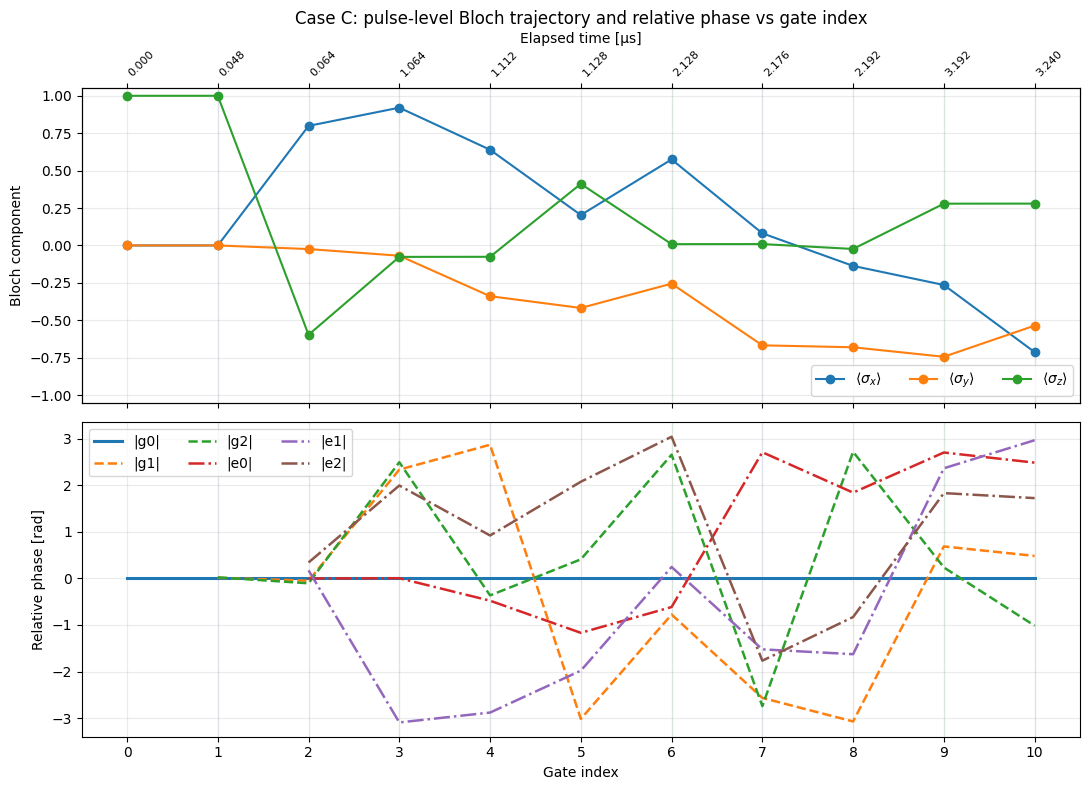

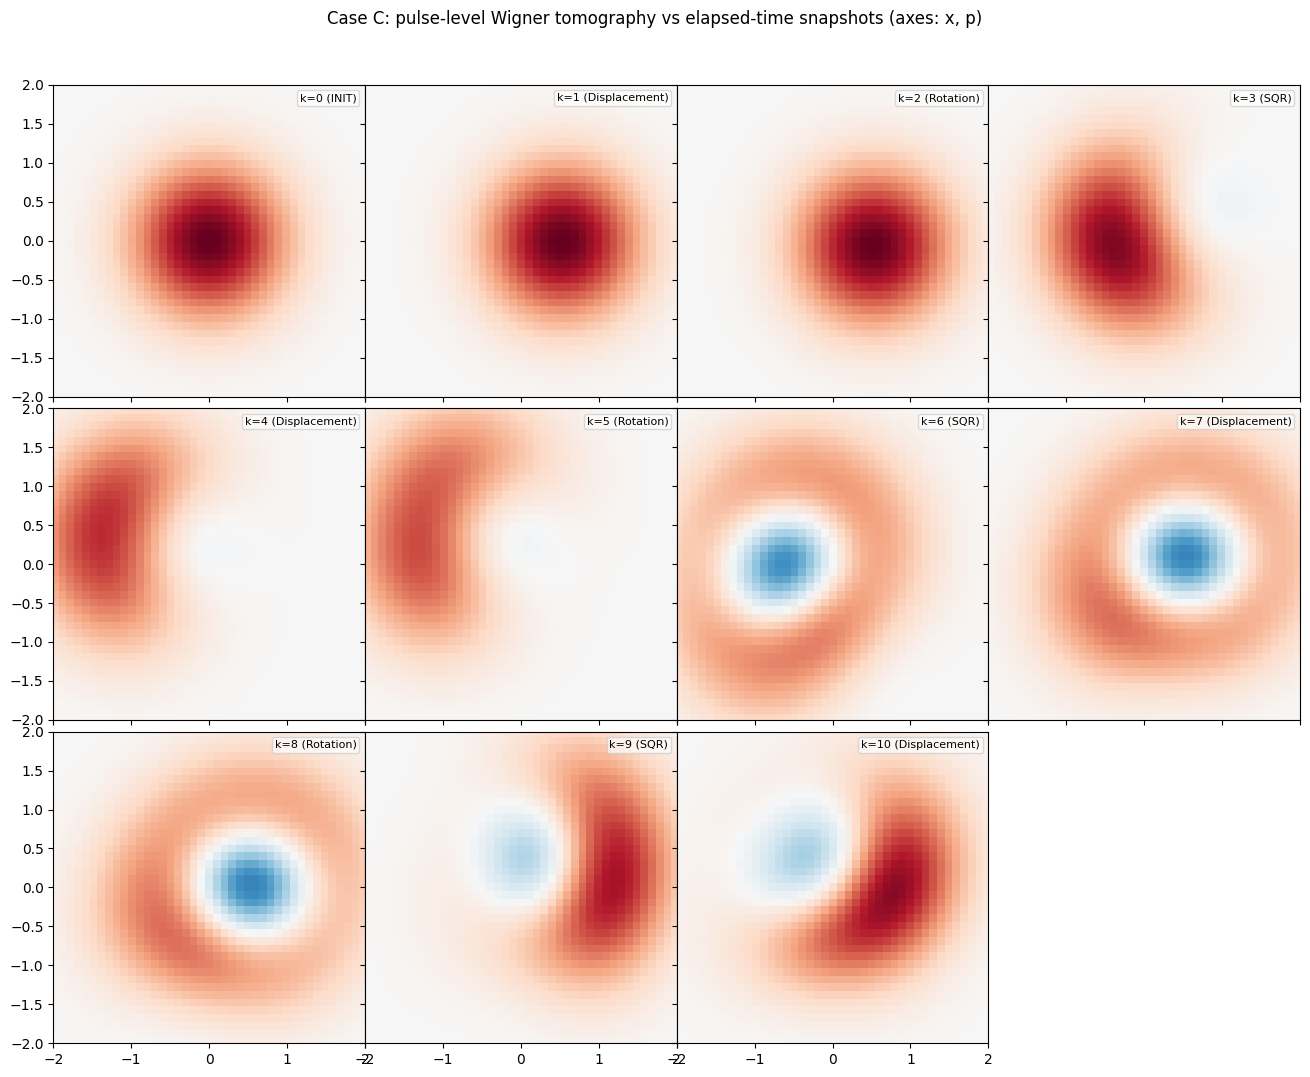

In [7]:
CASE_C = run_case_c(GATES, CONFIG, case_label="Case C")

print("Case C diagnostics:")
print(
    {
        "solver": CASE_C["metadata"]["solver"],
        "final_x": CASE_C["x"][-1],
        "final_y": CASE_C["y"][-1],
        "final_z": CASE_C["z"][-1],
        "final_n": CASE_C["n"][-1],
    }
)
noise = CASE_C["metadata"]["noise"]
print(
    {
        "t1_s": None if noise is None else noise.t1,
        "tphi_s": None if noise is None else noise.tphi,
        "kappa_1_per_s": None if noise is None else noise.kappa,
        "gamma1_1_per_s": None if noise is None else noise.gamma1,
        "gamma_phi_prefactor_1_per_s": None if noise is None else noise.gamma_phi,
    }
)
print("Case C gate-to-pulse mapping:")
print_mapping_rows(CASE_C)

elapsed_c_us = elapsed_time_axis_s(CASE_C, CONFIG) * 1.0e6
print(f"Case C total elapsed time [us]: {elapsed_c_us[-1]:.6f}")

plot_pulse_bloch_and_phase_vs_time(
    CASE_C,
    CONFIG,
    max_n=int(CONFIG["phase_track_max_n"]),
    threshold=float(CONFIG["phase_reference_threshold"]),
    unwrap=bool(CONFIG["phase_unwrap"]),
)
plt.show()

plot_wigner_grid(
    CASE_C,
    title="Case C: pulse-level Wigner tomography vs elapsed-time snapshots",
    stride=int(CONFIG["wigner_stride"]),
    max_cols=int(CONFIG["wigner_max_cols"]),
    show_colorbar=False,
)
plt.show()


## Section 8: Weakness Metrics and Comparison Plots

Definitions used here:

- **Wigner negativity**: `0.5 * (integral |W| dx dp - 1)`.
- **Fidelity-based weakness**: `1 - F(rho_case, rho_A)` referenced to Case A at the same gate index.


e:\Program Files\Python311\Lib\site-packages\qutip\core\data\expm.py:136: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
e:\Program Files\Python311\Lib\site-packages\qutip\core\data\expm.py:136: LinAlgWarning: Matrix is ill-conditioned. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


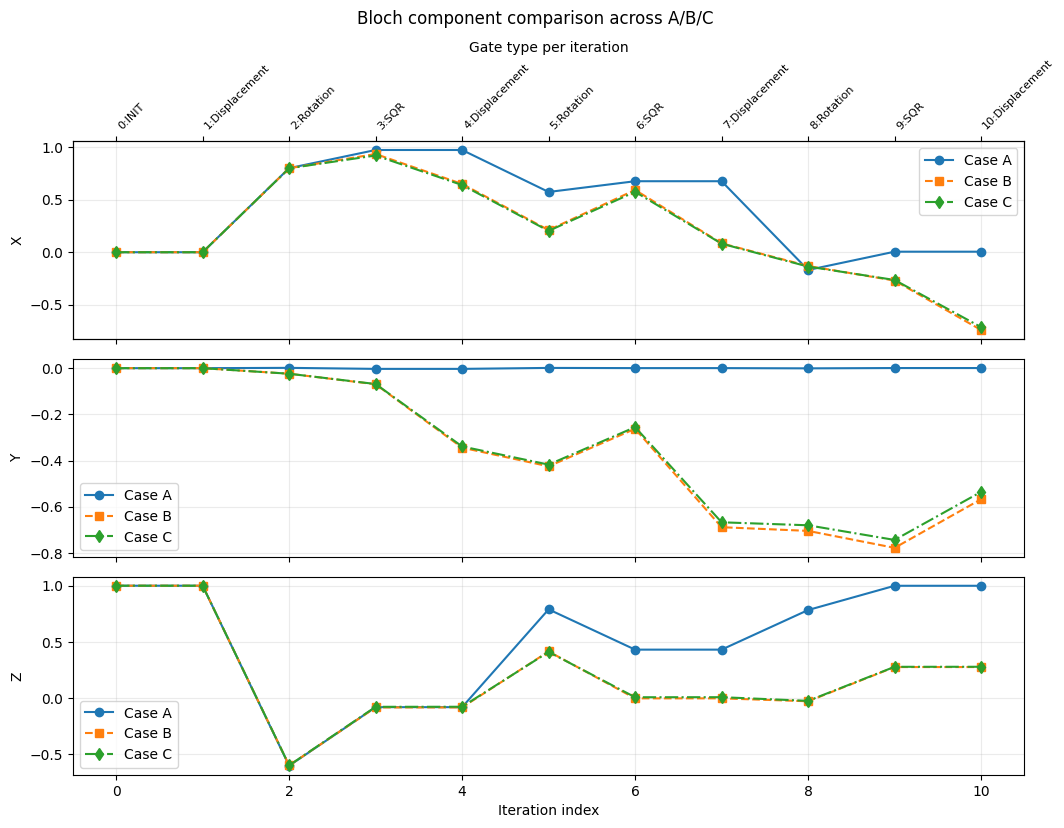

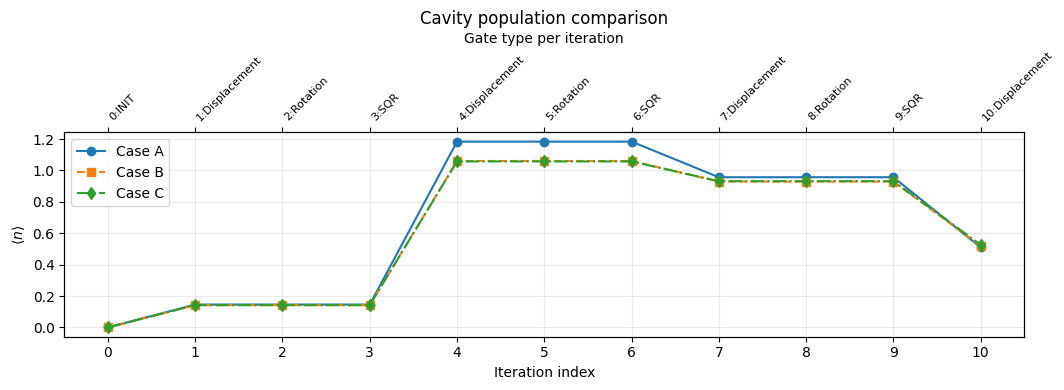

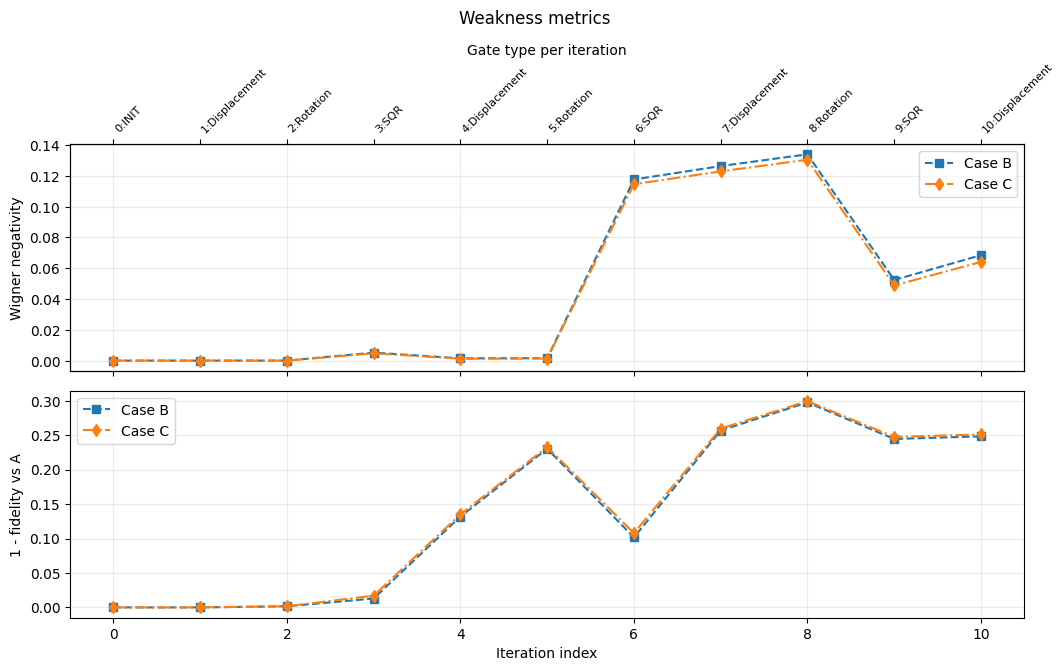

A vs B: {'x_rmse': 0.3338886437670658, 'y_rmse': 0.4544275024793819, 'z_rmse': 0.44893095000163946, 'n_rmse': 0.06617145056921526, 'final_fidelity': 0.7517605562279666}
A vs C: {'x_rmse': 0.33078300995922305, 'y_rmse': 0.4377467863587026, 'z_rmse': 0.4461937731620311, 'n_rmse': 0.06745792685401324, 'final_fidelity': 0.7490308518274795}


e:\Program Files\Python311\Lib\site-packages\qutip\core\data\expm.py:136: LinAlgWarning: Matrix is ill-conditioned. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


In [8]:
CASE_A = attach_weakness_metrics(CASE_A, CASE_A)
CASE_B = attach_weakness_metrics(CASE_A, CASE_B)
CASE_C = attach_weakness_metrics(CASE_A, CASE_C)

plot_component_comparison(
    CASE_A,
    CASE_B,
    CASE_C,
    label_stride=int(CONFIG["top_axis_label_stride"]),
)
plt.show()

plot_cavity_population_comparison(
    CASE_A,
    CASE_B,
    CASE_C,
    label_stride=int(CONFIG["top_axis_label_stride"]),
)
plt.show()

plot_weakness(
    CASE_B,
    CASE_C,
    reference_track=CASE_A,
    label_stride=int(CONFIG["top_axis_label_stride"]),
)
plt.show()

COMPARISON_AB = comparison_metrics(CASE_A, CASE_B)
COMPARISON_AC = comparison_metrics(CASE_A, CASE_C)
print("A vs B:", COMPARISON_AB)
print("A vs C:", COMPARISON_AC)


## Section 9: Test Suite


In [9]:
BASELINE_VS_REFACTOR = baseline_vs_refactor_sanity(CONFIG)
print("Baseline vs refactor sanity:", BASELINE_VS_REFACTOR)

TEST_RESULTS = run_notebook_sanity_suite(CONFIG)
for row in TEST_RESULTS:
    print(f"{row['status']}: {row['label']}")

TEST_RESULTS


Baseline vs refactor sanity: {'x_max_abs_err': 0.0, 'y_max_abs_err': 0.0, 'z_max_abs_err': 0.0, 'n_max_abs_err': 0.0}
PASS: Test 1: ideal rotation sanity
PASS: Test 2: Case B displacement sanity
PASS: Test 3: SQR conditionality
PASS: Test 4: decoherence limits
PASS: Test 5: Case A vs Case B ideal limit
PASS: Test 6: Case B/Case C shape and finiteness


[{'label': 'Test 1: ideal rotation sanity', 'status': 'PASS'},
 {'label': 'Test 2: Case B displacement sanity', 'status': 'PASS'},
 {'label': 'Test 3: SQR conditionality', 'status': 'PASS'},
 {'label': 'Test 4: decoherence limits', 'status': 'PASS'},
 {'label': 'Test 5: Case A vs Case B ideal limit', 'status': 'PASS'},
 {'label': 'Test 6: Case B/Case C shape and finiteness', 'status': 'PASS'}]

## Section 10: Final Summary Tables and Notes


In [10]:
FINAL_SUMMARIES = [final_case_summary(track) for track in (CASE_A, CASE_B, CASE_C)]
print("Final case summaries:")
for row in FINAL_SUMMARIES:
    print(row)

print("\nNotes:")
print("- Case A is the instantaneous-unitary baseline.")
print("- Case B and Case C use the same pulse shapes; Case C adds Lindblad dissipation.")
print("- SQR in Cases B/C uses a simplified multitone Gaussian selective-drive approximation tied to cqed_sim dispersive manifold frequencies.")
print("- Bloch plots intentionally keep gate-type labels only on the top x-axis to avoid duplication.")
print("- The baseline-vs-refactor check compares the refactored Case A path against an independent direct-unitary reference.")


Final case summaries:
{'case': 'Case A', 'solver': 'instantaneous_unitary', 'final_x': 0.005061829077818567, 'final_y': 0.0005559005790004141, 'final_z': 0.9995098045492457, 'final_n': 0.5095751996537795, 'final_qubit_purity': 0.9995228902645685, 'final_cavity_purity': 0.9995228902645689, 'final_wigner_negativity': 0.08238067367609514, 'final_fidelity_weakness_vs_a': -1.5827203769802622e-08}
{'case': 'Case B', 'solver': 'sesolve', 'final_x': -0.7401609584505687, 'final_y': -0.567592646609592, 'final_z': 0.2769836835148276, 'final_n': 0.5186464627518249, 'final_qubit_purity': 0.9733598089165942, 'final_cavity_purity': 0.9733598089165941, 'final_wigner_negativity': 0.06847624094911675, 'final_fidelity_weakness_vs_a': 0.24823944377203344}
{'case': 'Case C', 'solver': 'mesolve', 'final_x': -0.7127469803684212, 'final_y': -0.5356717786236507, 'final_z': 0.27956498636619004, 'final_n': 0.5270392604717896, 'final_qubit_purity': 0.9365545470200285, 'final_cavity_purity': 0.948433182742319, 'fi